# Coursework: Image Matching
### Visual Computing

This notebook contains exercises related to Part Two of  Coursework 2: Rendering and Image Matching,  CM22010 Visual Computing. It consists of two tasks: image stitching and panorama stitching. 

**Grading Scheme (6 points total)**:

- Task 1 **Image Stitching**: 3 points
- Task 2 **Panorama Stitching**: 3 points




### 1. Task 1 Image Stitching (3 points)
Image stitching involves aligning TWO images together to create a larger composite.

Note: You have to use your custom code (without using pre-built OpenCV libraries which would give one line of code of image stitching).


**Task description:**
- Stitching of two images together by finding corresponding points, aligning the images using a transformation.
- Optional: use blending techniques (such as linear blending) to avoid visible seams where the images overlap.

Corners img1: 1000
Corners img2: 1000


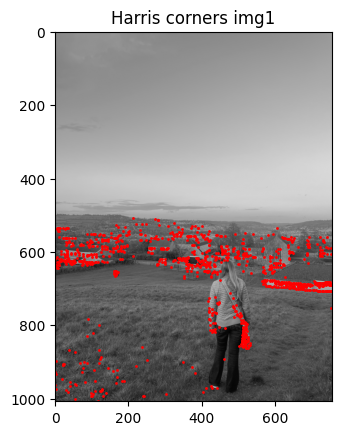

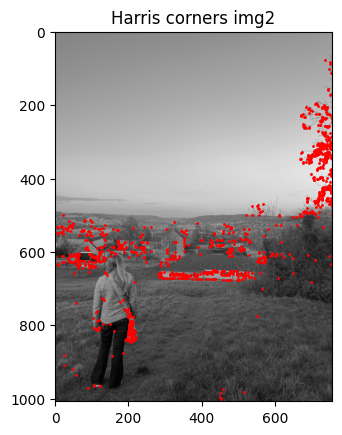

In [60]:
# Implement image stitching

# HELPFUL WEBSITE: https://kushalvyas.github.io/stitching.html
# 1. Image Registration
# 2. Calibration
# 3. Blending

import numpy as np
from PIL import Image 
import matplotlib.pyplot as plt
import random

img1 = Image.open("images/IMG_2.jpeg").convert("L") # load img1 as greyscale
img1 = img1.rotate(270, expand=True) # get it correct orientation
img1 = img1.resize((img1.width//4, img1.height//4)) # resize for faster convolution
grey1 = np.array(img1, dtype=np.float32) # convert to numpy array

plt.imshow(grey1, cmap="gray")

img2 = Image.open("images/IMG_4.jpeg").convert("L") # load img2 as greyscale
img2 = img2.rotate(270, expand=True) # get it correct orientation
img2 = img2.resize((img2.width//4, img2.height//4))# resize
grey2 = np.array(img2, dtype=np.float32) # convert to numpy array

# Sobel edge detection filters
sobel_x = np.array([
[-1,0,1],
[-2,0,2],
[-1,0,1]
])

sobel_y = np.array([
[-1,-2,-1],
[0,0,0],
[1,2,1]
])

from scipy.ndimage import convolve, maximum_filter

# def convolve(image, kernel):
#     h, w = image.shape
#     kh, kw = kernel.shape
#     pad = kh // 2

#     padded = np.pad(image, pad, mode="constant")
#     result = np.zeros_like(image)

#     for i in range(h):
#         for j in range(w):
#             region = padded[i:i+kh, j:j+kw]
#             result[i,j] = np.sum(region * kernel)
    
#     return result

def findHarrisCorners(image, top_k=1000):

    # compute gradients
    imgx = convolve(image, sobel_x)
    imgy = convolve(image, sobel_y)

    # compute Harris matrix components
    imgxx = imgx ** 2
    imgyy = imgy ** 2
    imgxy = imgx * imgy

    # sum values in a window
    window = np.ones((3, 3))

    Sxx = convolve(imgxx, window)
    Syy = convolve(imgyy, window)
    Sxy = convolve(imgxy, window)

    # compute harris corner response

    k = 0.04
    det = (Sxx * Syy) - (Sxy ** 2)
    trace = Sxx + Syy
    R = det - k * (trace ** 2)

    # # non-maximum suppression
    # suppressed = np.zeros_like(R)

    # window_size = 3
    # offset = window_size // 2

    # h, w = R.shape

    # for i in range(offset, h-offset):
    #     for j in range(offset, w-offset):
    #         region = R[i-offset:i+offset+1, j-offset:j+offset+1]

    #         if R[i, j] == np.max(region):
    #             suppressed[i, j] = R[i, j]

    local_max = maximum_filter(R, size=3)
    R[R < local_max] = 0

    # # find corners
    # threshold = 0.01 * suppressed.max()

    # corners = np.zeros_like(suppressed)
    # corners[suppressed > threshold] = 1    

    # # get corner coords
    # points = np.argwhere(corners == 1)

    # Adaptive thresholding
    floor_threshold = 1e-6
    coords = np.argwhere(R > floor_threshold)
    values = R[R > floor_threshold]

    if len(values) > top_k:
        idx = np.argsort(values)[-top_k:]
        points = coords[idx]
    else:
        points = coords

    # threshold = 0.01 * R.max()
    # points = np.argwhere(R > threshold)

    return np.array(points)

points1 = findHarrisCorners(grey1)
points2 = findHarrisCorners(grey2)

print("Corners img1:", len(points1))
print("Corners img2:", len(points2))

# plot corners
plt.imshow(grey1, cmap="gray")

y1, x1 = points1[:,0], points1[:,1]
plt.scatter(x1, y1, s=1, c="red")

plt.title("Harris corners img1")
plt.show()

plt.imshow(grey2, cmap="gray")

y2, x2 = points2[:,0], points2[:,1]
plt.scatter(x2, y2, s=1, c="red")

plt.title("Harris corners img2")
plt.show()
            


# ------------- NOTES -------------
# TODO:
# - match features
# - compute homography
# - warp images
# - blend panorama


# match features:
# - SIFT matching (scale invariant feature transform)
# compute image gradients in local 16x16 area at selected scale
# create an array of orientation histograms

# feature matching:
# - define distance function that compares two descriptors
# - test all features in I2, find the one with min distance

# RANSAC algorithm:
# - sample number of data points required to fit model
# - compute model parameters using sampled data points
# - score by fraction of inliers within a preset threshold of the model
# repeat 1-3 until best model is found with high confidence

# find homography:
# compute similar features in both images
# out of them, filter out good features
# Make an array of; 
#   features of image 1 ==> [srcPoints], 
#   features of image 2 ==> [dstPoints]
# Compute homography matrix using RANSAC algorithm


# feature-based alignment:
# - extract features
# - compute putative matches
# - loop:
#       hypothesise transformation T
#       verify transformation (search for other matches consistent with T)




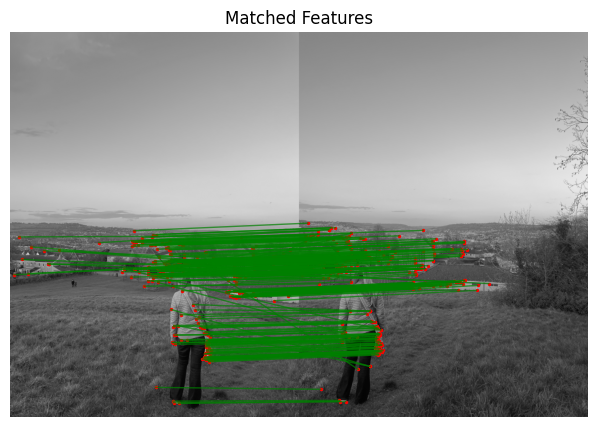

In [61]:
import matplotlib.cm as cm

def getPatch(img, point, size=8):
    y, x = point
    offset = size // 2

    if y-offset < 0 or y+offset >= img.shape[0]:
        return None
    if x-offset < 0 or x+offset >= img.shape[1]:
        return None

    patch = img[y-offset:y+offset+1, x-offset:x+offset+1]

    # normalize patch
    patch = patch - np.mean(patch)
    std = np.std(patch)
    if std != 0:
        patch = patch / std

    return patch.flatten()

def getAllPatches(img, points, size=9):
    h, w = img.shape
    offset = size // 2
    patches = []
    valid_points = []

    for y, x in points:
        if y - offset >= 0 and y + offset < h and x - offset >= 0 and x + offset < w:
            patch = img[y-offset : y+offset+1, x-offset : x+offset+1].flatten()

            patch_std = np.std(patch)
            if patch_std > 1e-5:
                patch = (patch - np.mean(patch)) / patch_std

            patches.append(patch)
            valid_points.append([y, x])
    
    return np.array(patches), np.array(valid_points)

def matchFeatures(img1, img2, points1, points2, patch_size=9):
    desc1, v_pts1 = getAllPatches(img1, points1, patch_size)
    desc2, v_pts2 = getAllPatches(img2, points2, patch_size)

    dist_matrix = np.sum(desc1**2, axis=1)[:, np.newaxis] + \
                  np.sum(desc2**2, axis=1) - \
                  2 * np.dot(desc1, desc2.T)
    
    sorted_indices = np.argsort(dist_matrix, axis=1)

    matches = []
    for i in range(len(desc1)):
        best_idx = sorted_indices[i, 0]
        second_best_idx = sorted_indices[i, 1]

        ratio = dist_matrix[i, best_idx] / (dist_matrix[i, second_best_idx] + 1e-10)

        if ratio < 0.7:
            matches.append((v_pts1[i], v_pts2[best_idx]))

    return matches

def matchPoints(img1, img2, points1, points2, max_matches=40):
    matches = []

    for p1 in points1:
        patch1 = getPatch(img1, p1)

        if patch1 is None:
            continue

        best_match = None
        best_dist = float("inf")

        for p2 in points2:
            patch2 = getPatch(img2, p2)

            if patch2 is None:
                continue
            
            dist = np.sum((patch1 - patch2) ** 2)
            
            if dist < best_dist:
                best_dist = dist
                best_match = p2

        if best_match is not None:
            matches.append((p1, best_match, best_dist))
    
    matches.sort(key=lambda x: x[2])

    matches = matches[:max_matches]

    return [(m[0], m[1]) for m in matches]

# matches = matchPoints(grey1, grey2, points1, points2, 40)
matches = matchFeatures(grey1, grey2, points1, points2)

h1, w1 = grey1.shape
h2, w2 = grey2.shape

height = max(h1, h2)
width = w1 + w2

combined = np.zeros((height, width))

combined[:h1, :w1] = grey1
combined[:h2, w1:w1+w2] = grey2

plt.figure(figsize=(10,5))
plt.imshow(combined, cmap="gray")

num_matches = len(matches)

# generate distinct colours

for i, (p1, p2) in enumerate(matches):
    line_colour = "green"
    dot_colour = "red"

    y1, x1 = p1
    y2, x2 = p2

    # shift x coordinate of image2
    x2_shifted = x2 + w1

    plt.plot([x1, x2_shifted], [y1, y2], color=line_colour, linewidth=1, alpha=0.7)
    plt.scatter(x1, y1, s=2, color=dot_colour)
    plt.scatter(x2_shifted, y2, s=2, color=dot_colour)

plt.title("Matched Features")
plt.axis("off")
plt.show()


In [62]:
import random

def computeHomography(matches):
    A = []

    for (p1, p2) in matches:
        y1, x1 = p1
        y2, x2 = p2

        A.append([
            -x1, -y1, -1, # coefficients for h11, h12, h13
            0, 0, 0,  # no contribution to second row of H
            x1*x2, y1*x2, x2 # coefficients involving h31, h32, h33
        ])

        A.append([
            0, 0, 0, # no contribution to first row of H
            -x1, -y1, -1, # coefficients of h21, h22, h23
            x1*y2, y1*y2, y2 # coefficients involving h31, h32, h33
        ])

    A = np.array(A)

    U, s, vt = np.linalg.svd(A)

    h = vt[-1]
    H = h.reshape(3, 3)
    
    return H / H[-1, -1] # normalise

# next step is using RANSAC to find the best random subset of matches that gives the most accurate homography 
def RANSAC(matches, threshold=2, iterations=1000):
    best_inliers = []
    bestH = None

    for i in range(iterations):
        sample = random.sample(matches, 4)
        H = computeHomography(sample)

        if np.linalg.matrix_rank(H) < 3:
            continue

        inliers = []

        for (p1, p2) in matches:
            y1, x1 = p1
            y2, x2 = p2

            p1_h = np.array([x1, y1, 1])

            p2_proj = H @ p1_h
            p2_proj /= p2_proj[2]

            error = np.linalg.norm(p2_proj[:2] - np.array([x2, y2]))

            if error < threshold:
                inliers.append((p1, p2))
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            bestH = H

    if best_inliers:
        bestH = computeHomography(best_inliers)

    return bestH

H = RANSAC(matches)

#### now warp one image into the other

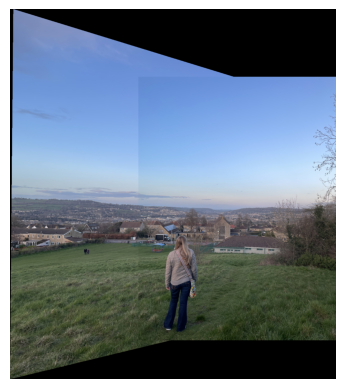

In [63]:
# ------ compute output canvas ------

h1, w1 = grey1.shape  # height, width
h2, w2 = grey2.shape

corners_img1 = [[0,0,1],[w1,0,1],[0,h1,1],[w1,h1,1]]
transformed = []
for c in corners_img1:
    p = H @ np.array(c)
    p /= p[2]
    transformed.append(p[:2])

corners_img2 = [[0,0,1],[w2,0,1],[0,h2,1],[w2,h2,1]]
all_points = transformed + [np.array(c[:2]) for c in corners_img2]

min_x = min(p[0] for p in all_points)
max_x = max(p[0] for p in all_points)
min_y = min(p[1] for p in all_points)
max_y = max(p[1] for p in all_points)

offset_x = int(-min_x)
offset_y = int(-min_y)
width  = int(max_x - min_x)
height = int(max_y - min_y)

output = np.zeros((height, width, 3), dtype=np.uint8)

img1_color = np.array(Image.open("images/IMG_2.jpeg").convert("RGB").rotate(270, expand=True).resize((w1, h1)))
img2_color = np.array(Image.open("images/IMG_4.jpeg").convert("RGB").rotate(270, expand=True).resize((w2, h2)))

H_inv = np.linalg.inv(H)

for y in range(height):
    for x in range(width):
        p = np.array([x - offset_x, y - offset_y, 1.0])
        p_src = H_inv @ p
        p_src /= p_src[2]
        x_src, y_src = p_src[0], p_src[1]
        if 0 <= x_src < w1 and 0 <= y_src < h1:
            output[y, x] = img1_color[int(y_src), int(x_src)]

# place img2 at its offset position
output[offset_y:offset_y+h2, offset_x:offset_x+w2] = img2_color

plt.imshow(output)
plt.axis("off")
plt.show()


### 2. Task 2 Panorama Stitching (3 points)
Panorama stitching involves aligning multiple images (minimally 3 images) to create a single wide-angle composite.

Note: You have to use your custom code (without using pre-built OpenCV libraries which would give one line of code of panorama stitching).

**Task description:**
- Implement panorama stitching with multiple images, at least three images.
- Use projective transformations to align images.
- Optional: You can explore techniques like feathering, linear blending for better panaromas.


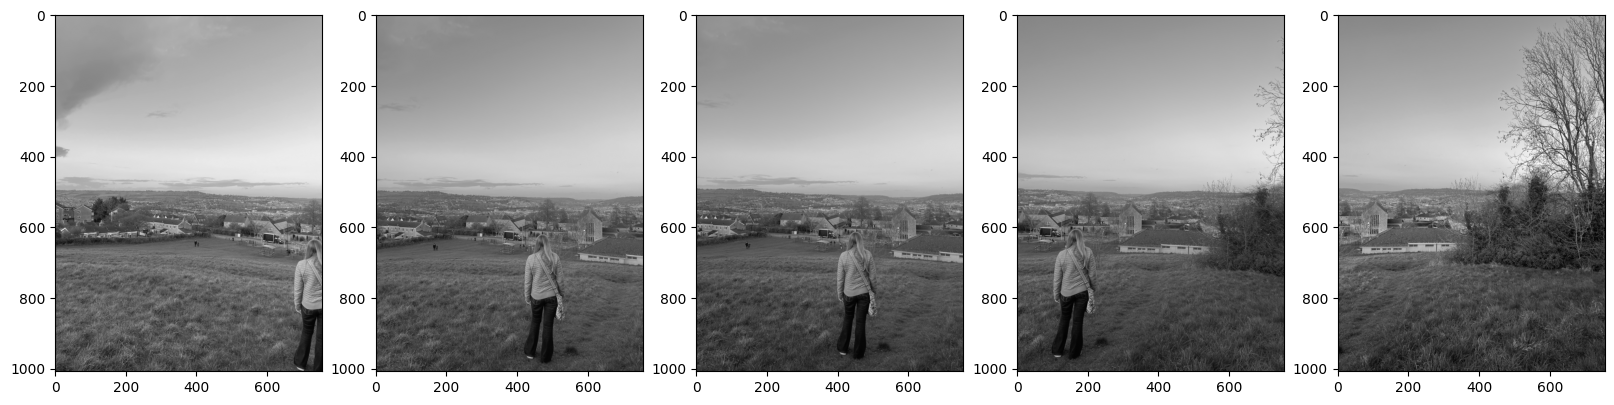

Corners img 0: 1000
Corners img 1: 1000
Corners img 2: 1000
Corners img 3: 1000
Corners img 4: 1000


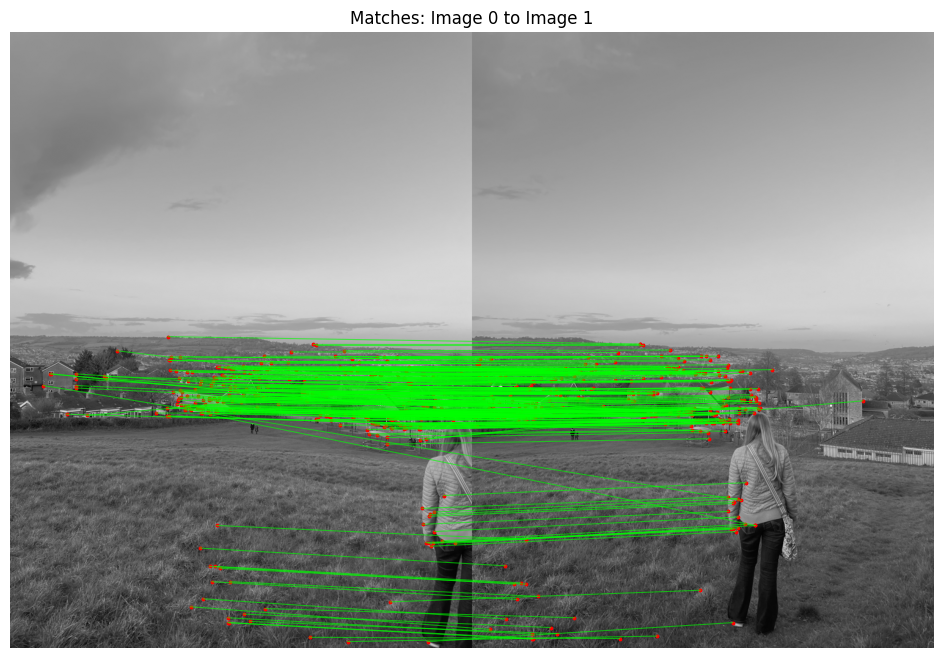

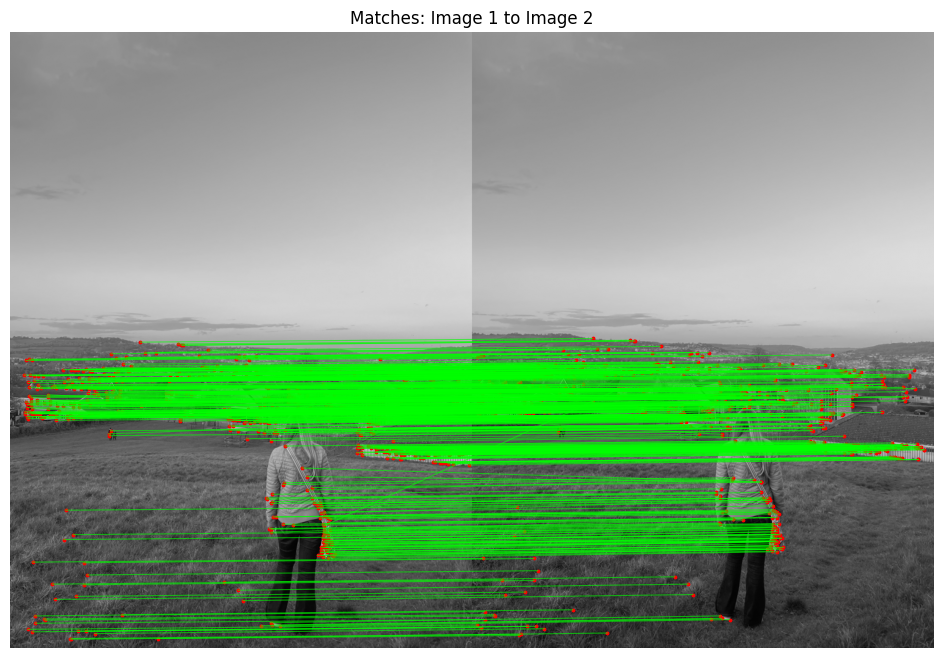

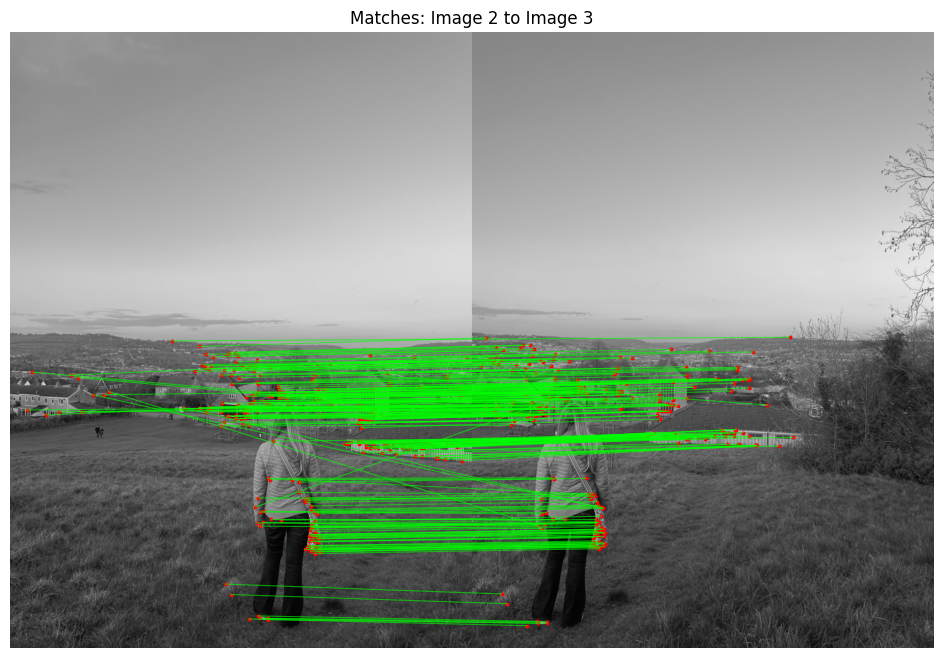

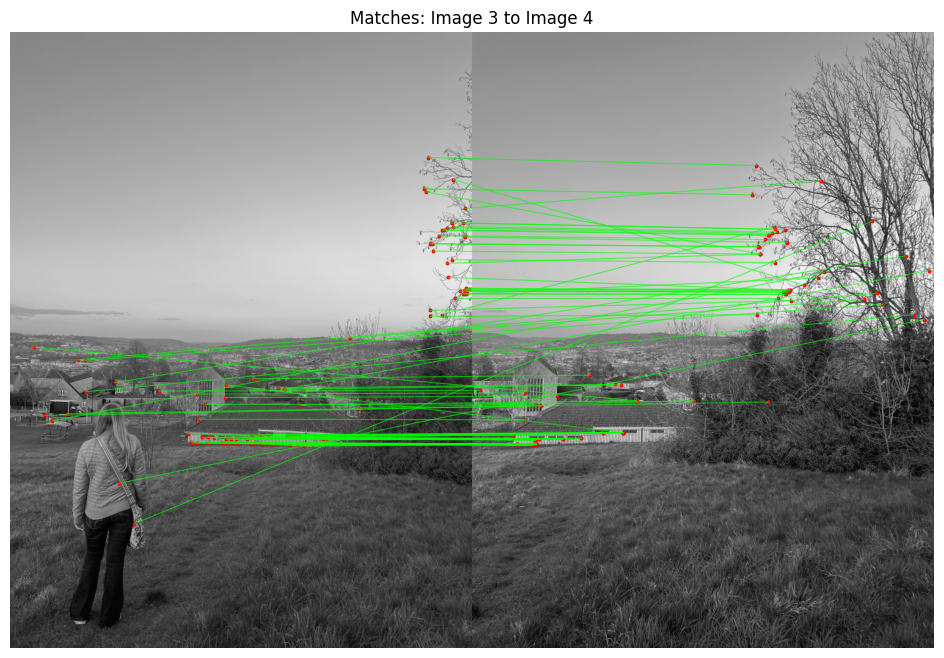

In [ ]:
# Code for Panorama Stitching here
# Implement panorama stitching techniques

import os

imgs = []

for file in os.listdir("images"):
    if file.endswith(".jpeg") or file.endswith(".jpg"):
        path = os.path.join("images", file)

        img = Image.open(path).convert("L")
        img = img.rotate(270, expand=True)
        img = img.resize((img.width//4, img.height//4))
        grey = np.array(img, dtype=np.float32)

        imgs.append(grey)

fig, axes = plt.subplots(1, 5, figsize=(20,5))

for i, img in enumerate(imgs):
    axes[i].imshow(img, cmap="gray")

plt.show()

points = []
matches = []
combined = [] # Initialize the list

for i in range(len(imgs)):
    corners = findHarrisCorners(imgs[i])
    points.append(corners)
    print(f"Corners img {i}: {len(corners)}")

for i in range(len(imgs) - 1):
    current_matches = matchFeatures(imgs[i], imgs[i+1], points[i], points[i+1])
    matches.append(current_matches)

    h1, w1 = imgs[i].shape
    h2, w2 = imgs[i+1].shape

    canvas = np.zeros((max(h1, h2), w1 + w2))
    canvas[:h1, :w1] = imgs[i]
    canvas[:h2, w1:w1+w2] = imgs[i+1]
    
    # plot this specific pair
    plt.figure(figsize=(16, 8))
    plt.imshow(canvas, cmap="gray")

    # draw match lines
    for p1, p2 in current_matches:
        y1, x1 = p1
        y2, x2 = p2
        
        # Plot match lines
        plt.plot([x1, x2 + w1], [y1, y2], color='lime', linewidth=0.8, alpha=0.6)
        # plot dots at the endpoints
        plt.scatter([x1, x2 + w1], [y1, y2], color='red', s=3)

    plt.title(f"Matches: Image {i} to Image {i+1}")
    plt.axis('off')
    plt.show()


In [69]:
# compute pairwise homographies
pairwise_H = []
for i in range(len(imgs) - 1):
    print(f"Matching {i} and {i+1}...")
    m = matchFeatures(imgs[i], imgs[i+1], points[i], points[i+1])
    H = RANSAC(m)
    pairwise_H.append(H)

# Assuming pairwise_H has 4 matrices: [H01, H12, H23, H34]
combined_H = [None] * len(imgs)

# Set the middle image as the identity (Reference)
mid = len(imgs) // 2 
combined_H[mid] = np.eye(3)

# Chain backwards from middle to the start
for i in range(mid - 1, -1, -1):
    combined_H[i] = combined_H[i+1] @ pairwise_H[i]

# Chain forwards from middle to the end
for i in range(mid + 1, len(imgs)):
    combined_H[i] = combined_H[i-1] @ np.linalg.inv(pairwise_H[i-1])

all_corners = []
for i, img in enumerate(imgs):
    h, w = img.shape
    c = np.array([[0, 0, 1], [w, 0, 1], [0, h, 1], [w, h, 1]]).T
    p = combined_H[i] @ c
    p /= p[2, :]
    all_corners.append(p[:2, :])

all_corners = np.hstack(all_corners)
min_x, min_y = np.floor(all_corners.min(axis=1)).astype(int)
max_x, max_y = np.ceil(all_corners.max(axis=1)).astype(int)

# Create final canvas
out_w = max_x - min_x
out_h = max_y - min_y
panorama = np.zeros((out_h, out_w, 3), dtype=np.uint8)

colour_imgs = []
for file in sorted(os.listdir("images")):
    if file.endswith(".jpeg") or file.endswith(".jpg"):
        c_img = Image.open(os.path.join("images", file)).rotate(270, expand=True)

        h_target, w_target = imgs[len(colour_imgs)].shape
        c_img = c_img.resize((w_target, h_target))
        colour_imgs.append(np.array(c_img))

# inverse warping loop
for i in range(len(imgs)):
    print(f"Warping Image {i}...")
    H_inv = np.linalg.inv(combined_H[i])
    h_src, w_src = imgs[i].shape

    img_corners = all_corners[i]

    curr_min_x = int(np.floor(img_corners[0].min()))
    curr_max_x = int(np.ceil(img_corners[0].max()))
    curr_min_y = int(np.floor(img_corners[1].min()))
    curr_max_y = int(np.ceil(img_corners[1].max()))

    for y in range(curr_min_y, curr_max_y):
        for x in range(curr_min_x, curr_max_x):
            p_src = H_inv @ np.array([x, y, 1.0])
            if abs(p_src[2]) < 1e-10: continue

            p_src /= p_src[2]
            x_s, y_s = int(p_src[0]), int(p_src[1])
            
            if 0 <= x_s < w_src and 0 <= y_s < h_src:
                pan_x = x - min_x
                pan_y = y - min_y

                if 0 <= pan_x < out_w and 0 <= pan_y < out_h:
                    if np.all(panorama[pan_y, pan_x] == 0):
                        panorama[pan_y, pan_x] = color_imgs[i][y_s, x_s]

plt.figure(figsize=(20, 10))
plt.imshow(panorama)
plt.axis("off")
plt.title("5-Image Panorama Stitch")
plt.show()

Matching 0 and 1...
Matching 1 and 2...
Matching 2 and 3...
Matching 3 and 4...
Warping Image 0...
Warping Image 1...
Warping Image 2...


IndexError: index 2 is out of bounds for axis 0 with size 2